# Imports

In [3]:
#-----------------------------------------------
# Imports
#-----------------------------------------------

from scipy.integrate import quad
from scipy.fftpack import fft

import matplotlib.pyplot as plt
import math as m
import numpy as np

# Задание 1а

<function matplotlib.pyplot.show(close=None, block=None)>

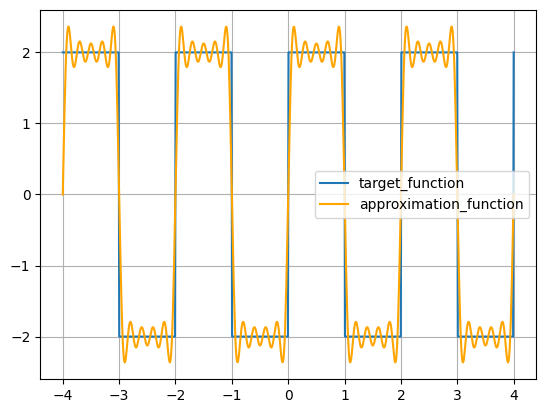

In [4]:
#-----------------------------------------------
# Задание 1 (а)
#-----------------------------------------------
def f(x, T=2):
    x_mod = x % T
    if x_mod < 1:
        return 2
    else:
        return -2
    
def int_err(integr):
    return integr[1]

def int_value(integr):
    return integr[0]
    
x = np.linspace(-4, 4, 800)
x_t = [f(t) for t in x]
plt.plot(x, x_t, label="target_function")
plt.grid(True)
plt.legend()
# plt.show()
T = 2
w = 2 * m.pi / T
N = 10 # Количество гармоник

def a_0(T=T):
    res = 2 / T * int_value(quad(f, 0, T)) 
    return res

def a_n(n, T=T, w=w):
    func_cos = lambda t: f(t) * m.cos(n * w * t)
    res = 2 / T * int_value(quad(func_cos, 0, T))
    return res

def b_n(n, T=T, w=w):
    func_sin = lambda t: f(t) * m.sin(n * w * t)
    res = 2 / T * int_value(quad(func_sin, 0, T))
    return res

a0 = a_0()
an_coeffs = [a_n(n)for n in range(1, N+1)]
bn_coeffs = [b_n(n)for n in range(1, N+1)]


x_t_star = []

for t in x:

    series_sum = a0 / 2

    for n in range(1, N + 1):
        series_sum += (an_coeffs[n-1] * m.cos(n * w * t) +
                       bn_coeffs[n-1] * m.sin(n * w * t) )
        
    x_t_star.append(series_sum)

plt.plot(x, x_t_star, color='orange', label="approximation_function")
plt.grid(True)
plt.legend()
plt.show
# print(x_t_star)

# Задание 1б

<function matplotlib.pyplot.show(close=None, block=None)>

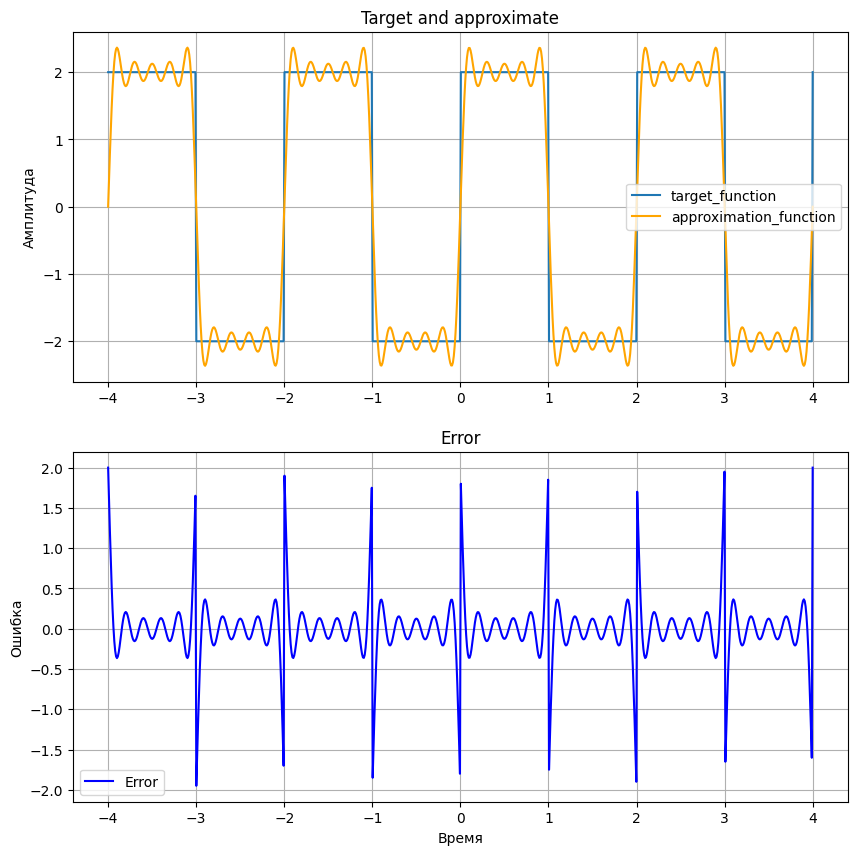

In [5]:
#-----------------------------------------------
# Задание 1 (б)
#-----------------------------------------------

eps = np.array(x_t) - np.array(x_t_star)

fig, axes = plt.subplots(2, 1, figsize=(10, 10))

axes[0].plot(x, x_t, label="target_function")
axes[0].plot(x, x_t_star, color='orange', label="approximation_function")
axes[0].grid(True)
axes[0].legend()
axes[0].set_title("Target and approximate")
axes[0].set(ylabel="Амплитуда")

axes[1].plot(x, eps, color="blue", label="Error")
axes[1].grid(True)
axes[1].legend()
axes[1].set_title("Error")
axes[1].set(xlabel='Время', ylabel="Ошибка")
plt.show

# Задание 1в

In [8]:
#-----------------------------------------------
# Задание 1 (в)
#-----------------------------------------------

class Fourie:
    def __init__(self, f, T, X, N):
        self.a0 = 0
        self.an = []
        self.bn = []
        self.w = 2 * m.pi / T
        self.T = T
        self.space = X
        self.approx_func = f
        self.fourie_row = []
        self.N = N
        
    def _compute_a0(self):
        self.a0 = 2 / self.T * int_value(quad(self.approx_func, 0, self.T)) 

    def _compute_an(self, n):
        func_cos = lambda t: self.approx_func(t) * m.cos(n * self.w * t)
        return 2 / self.T * int_value(quad(func_cos, 0, self.T))

    def _compute_bn(self, n):
        func_sin = lambda t: self.approx_func(t) * m.sin(n * self.w * t)
        return 2 / self.T * int_value(quad(func_sin, 0, self.T))

    def _compute_coeffs(self):
        self.an = [self._compute_an(n) for n in range(1, self.N + 1)]
        self.bn = [self._compute_bn(n) for n in range(1, self.N + 1)]


    def compute_row(self):

        self._compute_a0()
        self._compute_coeffs()
        

        for t in self.space:
            series_sum = self.a0 / 2

            for n in range(1, self.N + 1):
                series_sum += self.an[n - 1] * m.cos(n * self.w * t) + self.bn[n - 1] * m.sin(n * self.w * t)

            self.fourie_row.append(series_sum)

    def clear_row(self):
        self.fourie_row = []        
    
    def get_row(self):
        return self.fourie_row

## Тест класса на меандре

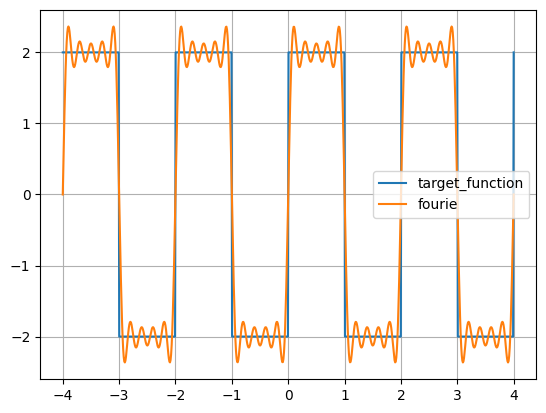

In [9]:


fourie_row = Fourie(f, T, x, 10)

fourie_row.compute_row()

row = fourie_row.get_row()

plt.plot(x, x_t, label="target_function")
plt.grid(True)
plt.legend()
# plt.show()
plt.plot(x, row, label="fourie")
plt.grid(True)
plt.legend()
plt.show()

# Задание 2 - проверка класса на cos

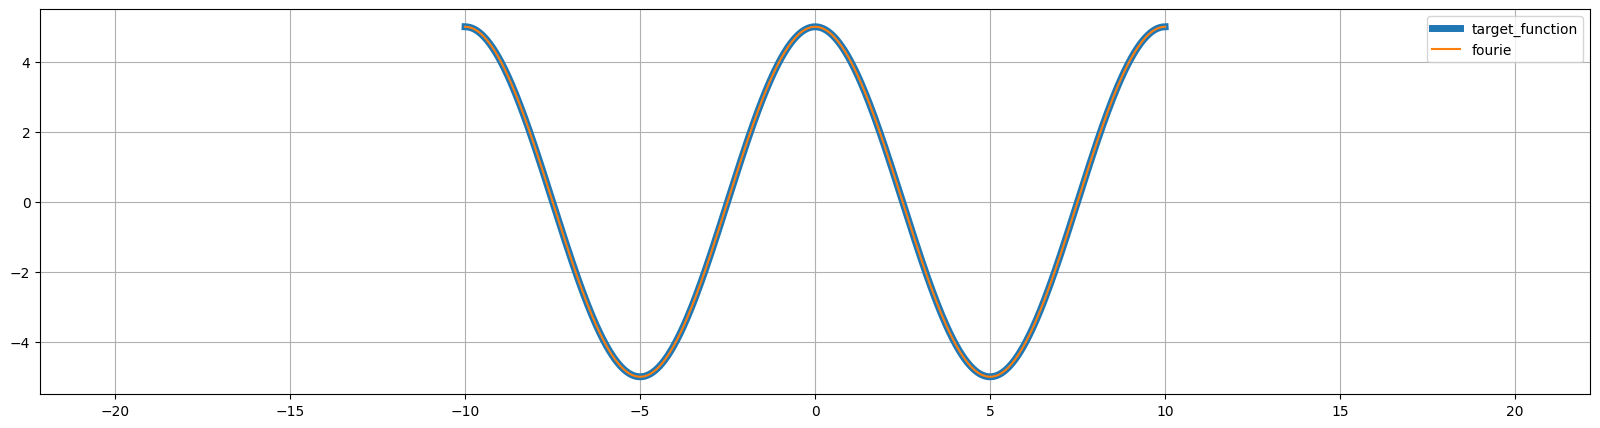

In [10]:
#-----------------------------------------------
# Задание 2
#-----------------------------------------------

x = np.linspace(-10, 10, 1000)

A = 5
freq = 100
w = 2 * m.pi * freq

def cos_A(t):
    return A * m.cos(t * w)

x_t_cos = [cos_A(t) for t in x]

furry = Fourie(cos_A, 1 / freq, x, 10)

furry.compute_row()

row = furry.get_row()


plt.figure(figsize=(20, 5)) 
plt.plot(x, x_t_cos, label="target_function", linewidth=5)

plt.grid(True)
plt.legend()
# plt.show()
plt.plot(x, row, label="fourie")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

## Наш алгоритм Преобразования Фурье

In [11]:
def DFT_slow(x):
    """Compute the discrete Fourier Transform of 1D array x"""
    x = np.asarray(x, dtype=float)
    N = x.shape[0]
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, x)

## Example:

Text(0, 0.5, 'Амплитуда')

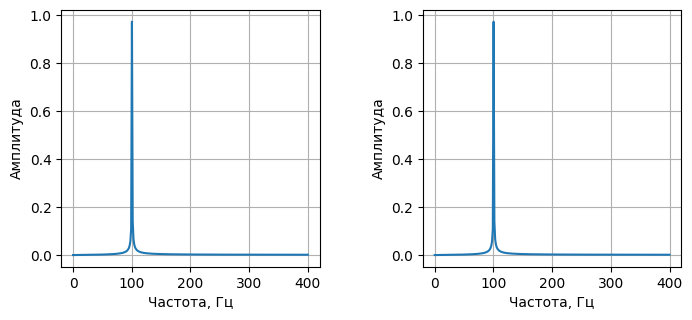

In [12]:
N = 600 # Количество отсчетов
fmax=800 # максимальная частота
T = 1.0/fmax #
f=100 # частота сигнала в Гц
x = np.linspace(0.0, N*T, N)
y = np.sin(f * 2.0*np.pi*x) #
yf = DFT_slow(y)
xf = np.linspace(0.0, fmax/2, N//2)
yff = fft(y)
fig = plt.figure(figsize=(8,8)) # размер полотна
plt.subplots_adjust(wspace=0.4, hspace=0.4) # отступ между графиками
plt.subplot(221)
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.grid()
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.subplot(222)
plt.plot(xf, 2.0/N * np.abs(yff[0:N//2]))
plt.grid()
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')

In [13]:
%timeit DFT_slow(x)
%timeit np.fft.fft(x)

18.1 ms ± 1.35 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
33.5 μs ± 3.63 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Пример на меандре

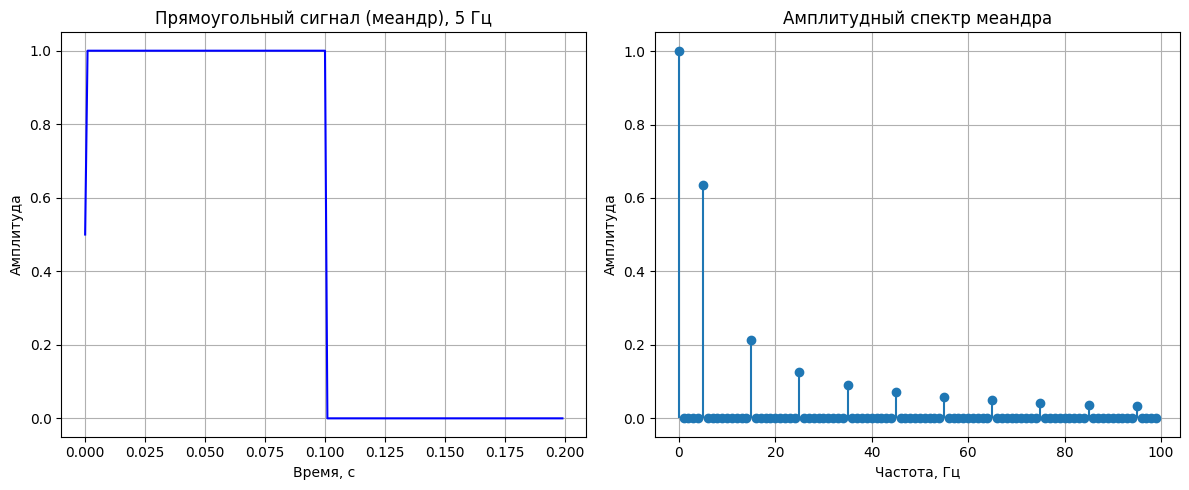

In [14]:
#-----------------------------------------------
# Алгоритм из numpy
#-----------------------------------------------

# Параметры сигнала
Fs = 1000          # частота дискретизации, Гц
T = 1.0            # длительность сигнала, с
N = int(Fs * T)    # количество отсчётов
t = np.arange(N) / Fs

# Генерируем меандр частотой 5 Гц
f_square = 5
square_wave = 0.5 * (1 + np.sign(np.sin(2 * np.pi * f_square * t)))  # значения 0 или 1
# Чтобы амплитуда была от -1 до 1 (как у косинуса), можно сделать:
# square_wave = np.sign(np.sin(2 * np.pi * f_square * t))

# Вычисляем БПФ
X = np.fft.fft(square_wave)
freq = np.fft.fftfreq(N, d=1/Fs)[:N//2]
X_one_sided = np.abs(X[:N//2]) * 2 / N

# Построение временной формы и спектра
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t[:200], square_wave[:200], 'b-')  # покажем первые 200 отсчётов
plt.title('Прямоугольный сигнал (меандр), 5 Гц')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(freq[:100], X_one_sided[:100], basefmt=" ")  # первые 100 частот для наглядности
plt.title('Амплитудный спектр меандра')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()
plt.show()

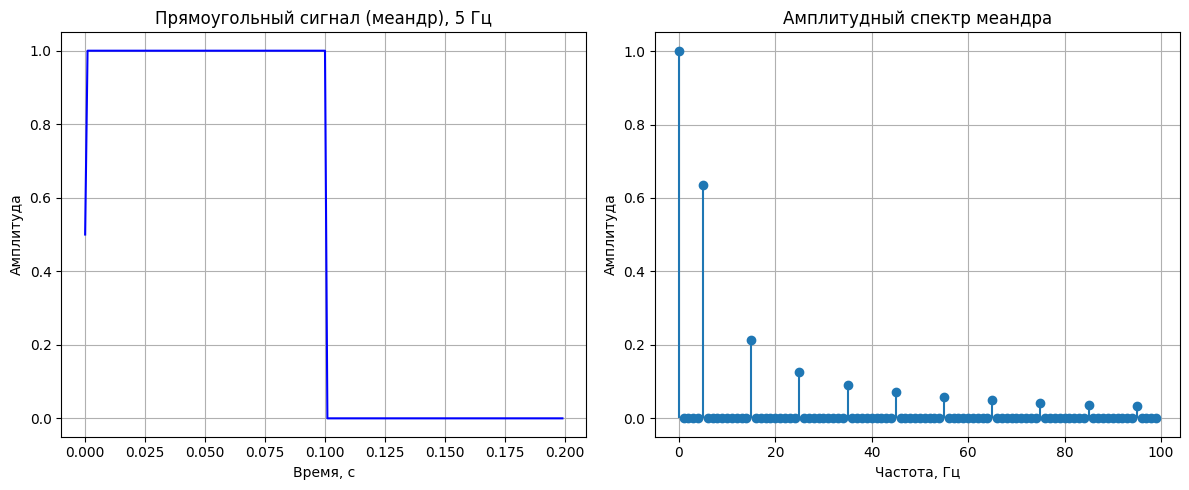

In [15]:
#-----------------------------------------------
# Мой алгоритм
#-----------------------------------------------
def DFT_slow(x):
    """Compute the discrete Fourier Transform of 1D array x"""
    x = np.asarray(x, dtype=float)
    N = x.shape[0]
    n = np.arange(N)
    k = n.reshape((N, 1))
    M = np.exp(-2j * np.pi * k * n / N)
    return np.dot(M, x)

# Параметры сигнала
Fs = 1000          # частота дискретизации, Гц
T = 1.0            # длительность сигнала, с
N = int(Fs * T)    # количество отсчётов
t = np.arange(N) / Fs

# Генерируем меандр частотой 5 Гц
f_square = 5
square_wave = 0.5 * (1 + np.sign(np.sin(2 * np.pi * f_square * t)))  # значения 0 или 1
# Чтобы амплитуда была от -1 до 1 (как у косинуса), можно сделать:
# square_wave = np.sign(np.sin(2 * np.pi * f_square * t))

# Вычисляем БПФ
X = DFT_slow(square_wave)
freq = np.arange(N // 2) * Fs / N
X_one_sided = np.abs(X[:N//2]) * 2 / N

# Построение временной формы и спектра
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t[:200], square_wave[:200], 'b-')  # покажем первые 200 отсчётов
plt.title('Прямоугольный сигнал (меандр), 5 Гц')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.stem(freq[:100], X_one_sided[:100], basefmt=" ")  # первые 100 частот для наглядности
plt.title('Амплитудный спектр меандра')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()
plt.show()

# Задание 2а

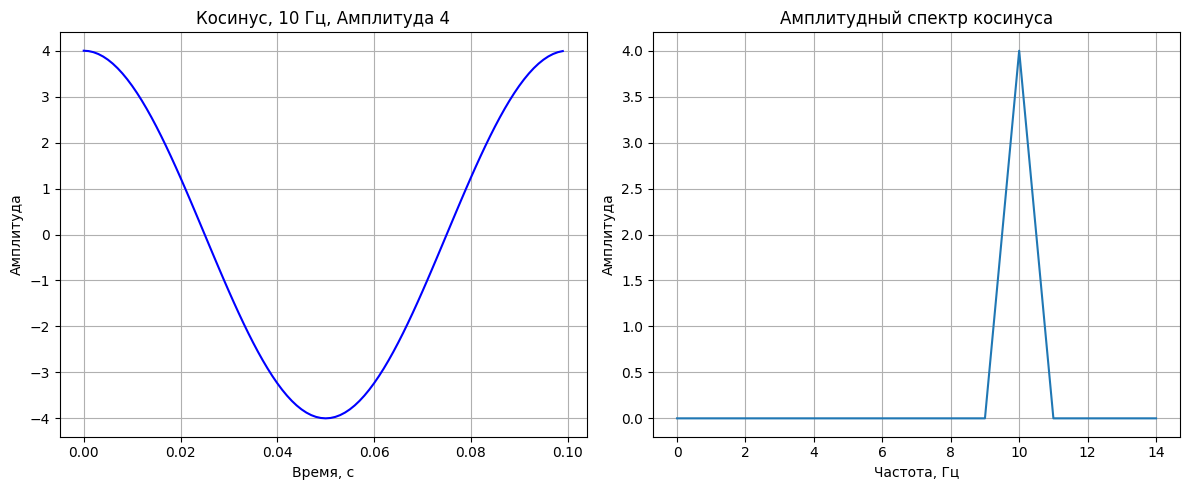

In [20]:
#-----------------------------------------------
# Задание 2 (а)
#-----------------------------------------------
# Параметры сигнала
Fs = 1000          # частота дискретизации, Гц
T = 1.0            # длительность сигнала, с
N = int(Fs * T)    # количество отсчётов
t = np.arange(N) / Fs
A = 4
freq = 10
w = 2 * np.pi * freq

fcos = A * np.cos(w * t)

X = np.fft.fft(fcos)
freq = np.fft.fftfreq(N, d=1/Fs)[:N//2]
X_one_sided = np.abs(X[:N//2]) * 2 / N

# Построение временной формы и спектра
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t[:100], fcos[:100], 'b-')  # покажем первые 200 отсчётов
plt.title('Косинус, 10 Гц, Амплитуда 4')
plt.xlabel('Время, с')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(freq[:15], X_one_sided[:15], )  # Покажем спектр. для plt.stem: basefmt=" "
plt.title('Амплитудный спектр косинуса')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

plt.tight_layout()
plt.show()


# Задание 2в

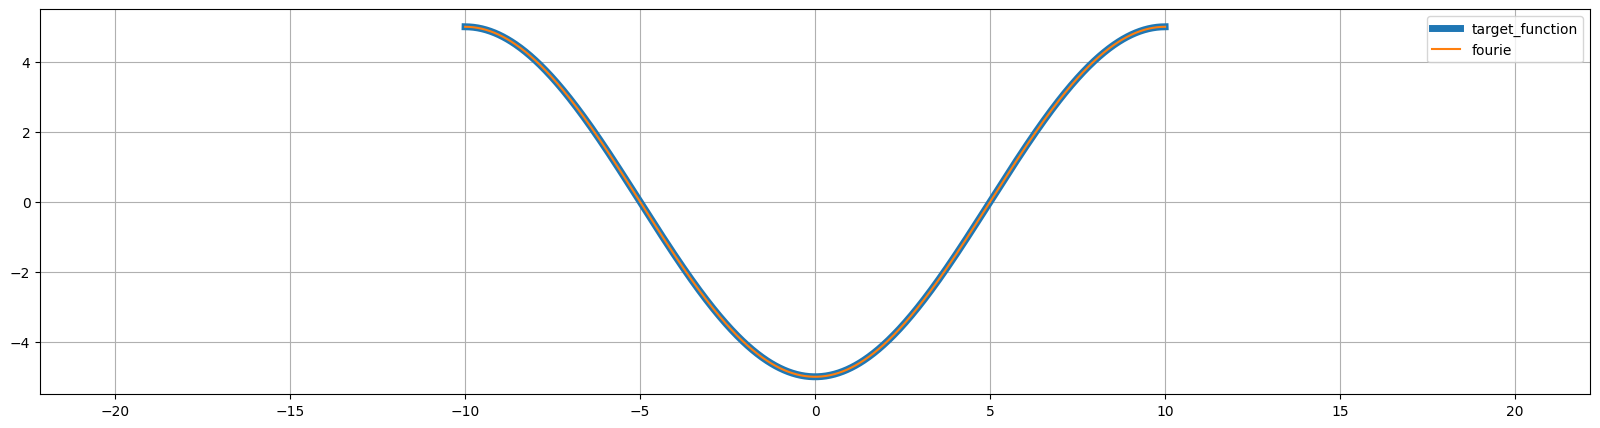

Спектральный коэффициент a1 = 5.0000 (ожидается A = 5)
Амплитуда первой гармоники = 5.0000


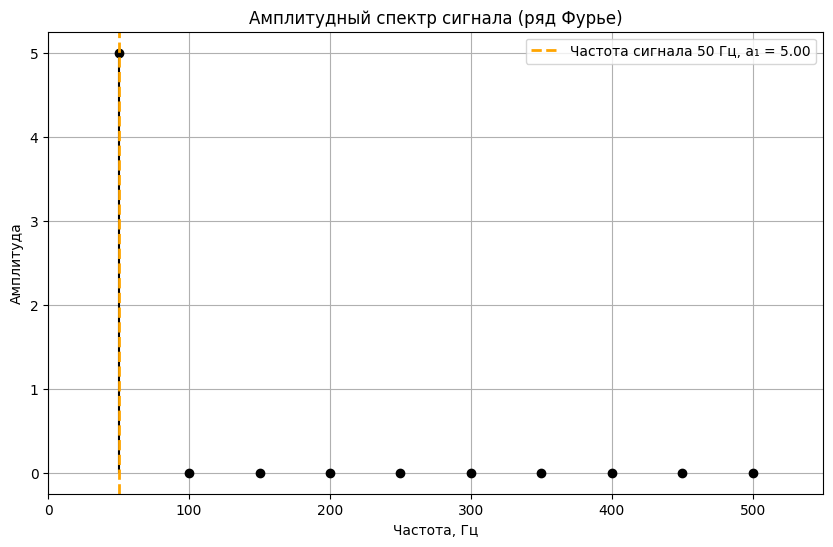

In [22]:
#-----------------------------------------------
# Задание 2
#-----------------------------------------------

x = np.linspace(-10, 10, 1000)

A = 5
freq = 50
w = 2 * m.pi * freq

def cos_A(t):
    return A * m.cos(t * w)

x_t_cos = [cos_A(t) for t in x]

furry = Fourie(cos_A, 1 / freq, x, 10)

furry.compute_row()

row = furry.get_row()


plt.figure(figsize=(20, 5)) 
plt.plot(x, x_t_cos, label="target_function", linewidth=5)

plt.grid(True)
plt.legend()
# plt.show()
plt.plot(x, row, label="fourie")
plt.axis('equal')
plt.grid(True)
plt.legend()
plt.show()

#-----------------------------------------------
# Задание 2 (в)
#-----------------------------------------------

f0 = freq  # основная частота (Гц)
n_harmonics = np.arange(1, furry.N + 1)  # номера гармоник от 1 до N
harmonics_freq = n_harmonics * f0        # частоты гармоник

# Амплитуды гармоник (для n >= 1)
amplitudes = [np.sqrt(furry.an[i]**2 + furry.bn[i]**2) for i in range(furry.N)]

# Поиск индекса основной гармоники (n=1) — это первый элемент
idx_fundamental = 0
a1 = furry.an[idx_fundamental]          # спектральный коэффициент a1
amp1 = amplitudes[idx_fundamental]       # амплитуда первой гармоники

print(f'Спектральный коэффициент a1 = {a1:.4f} (ожидается A = {A})')
print(f'Амплитуда первой гармоники = {amp1:.4f}')

# Создаём новый рисунок для спектра
plt.figure(figsize=(10, 6))

# Изображаем спектр в виде вертикальных линий (stem-plot)
plt.stem(harmonics_freq, amplitudes, basefmt=" ", linefmt='k-', markerfmt='ko')
plt.title('Амплитудный спектр сигнала (ряд Фурье)')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

# Отмечаем частоту сигнала оранжевой пунктирной линией
plt.axvline(x=f0, color='orange', linestyle='--', linewidth=2,
            label=f'Частота сигнала {f0} Гц, a₁ = {a1:.2f}')

plt.legend()
plt.xlim(0, max(harmonics_freq) * 1.1)  # небольшой запас справа
plt.show()

/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_7105/3121379190.py:22: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return 2 / self.T * int_value(quad(func_cos, 0, self.T))


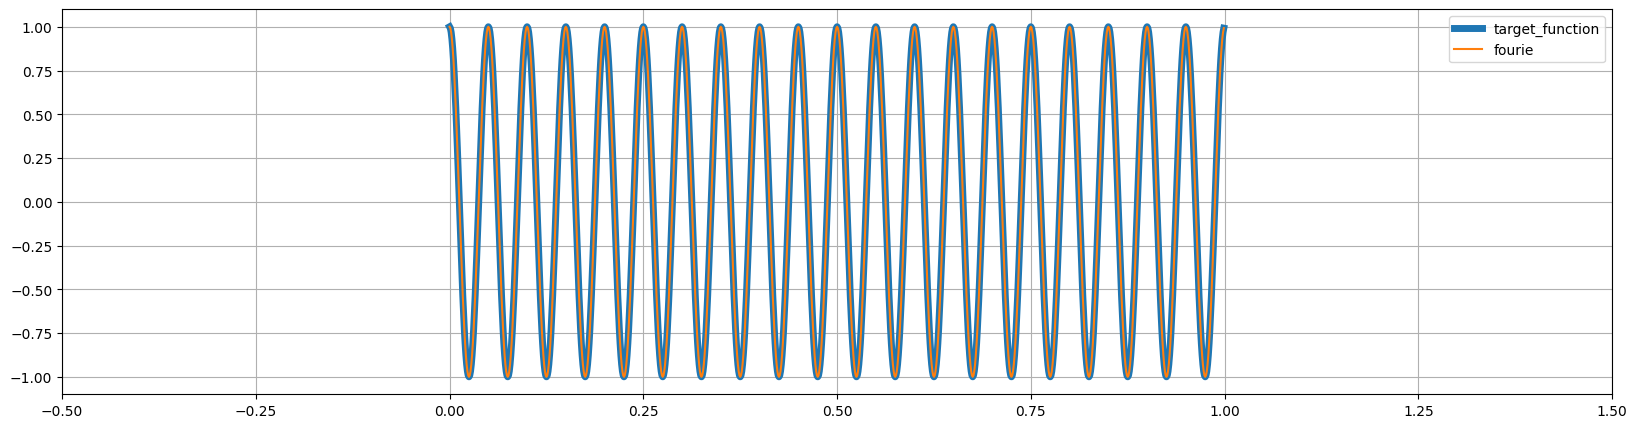

Спектральный коэффициент a1 = 1.0000 (ожидается A = 1)
Амплитуда первой гармоники = 1.0000


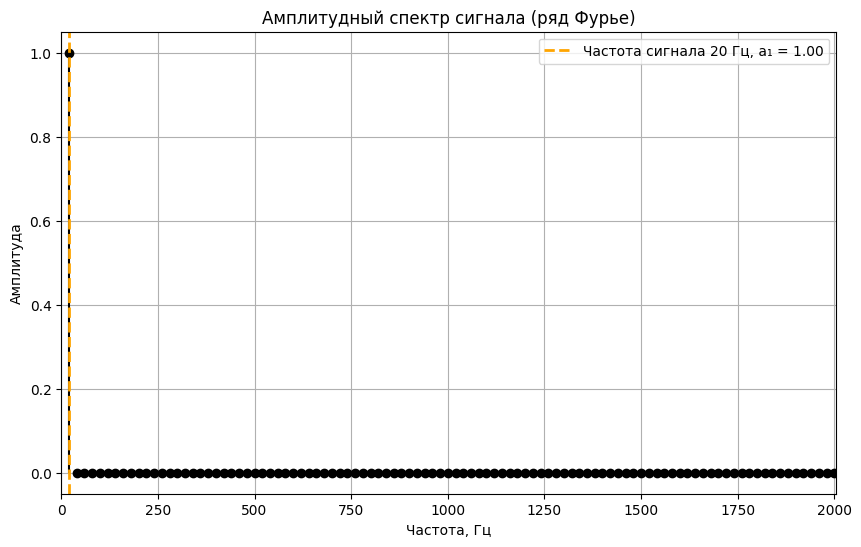

/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_7105/3121379190.py:18: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  self.a0 = 2 / self.T * int_value(quad(self.approx_func, 0, self.T))
/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_7105/3121379190.py:22: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  return 2 / self.T * int_value(quad(func_cos, 0, self.T))
/var/folders/l5/1_g08l313298yj0kplr9hs7r0000gn/T/ipykernel_7105/3121379190.py:26: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increa

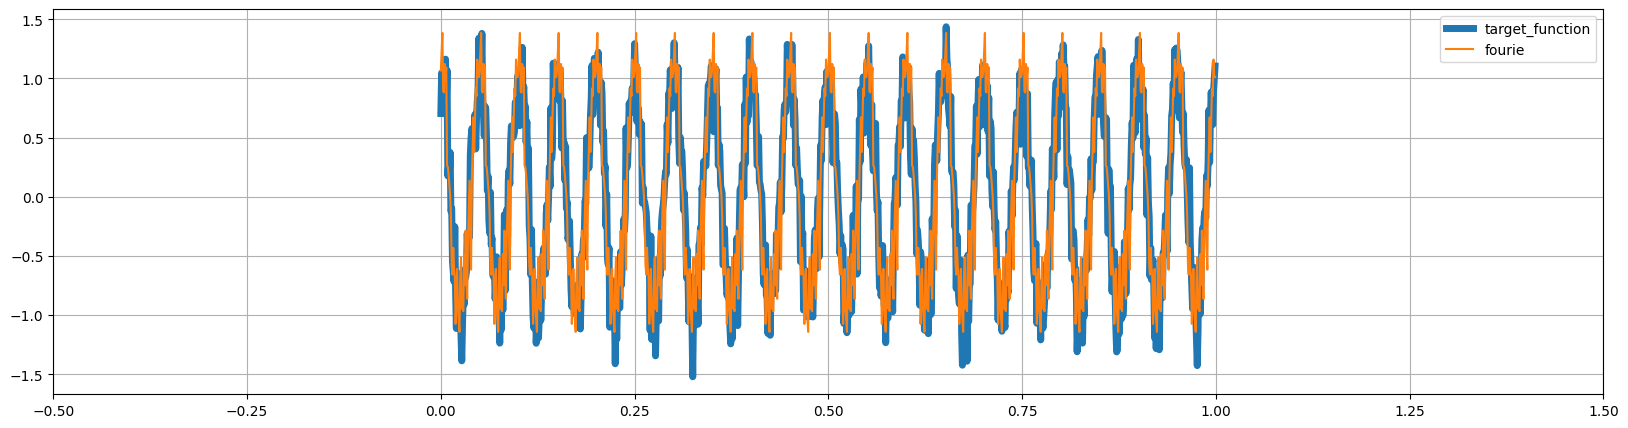

Спектральный коэффициент a1 = 1.0130 (ожидается A = 1)
Амплитуда первой гармоники = 1.0130


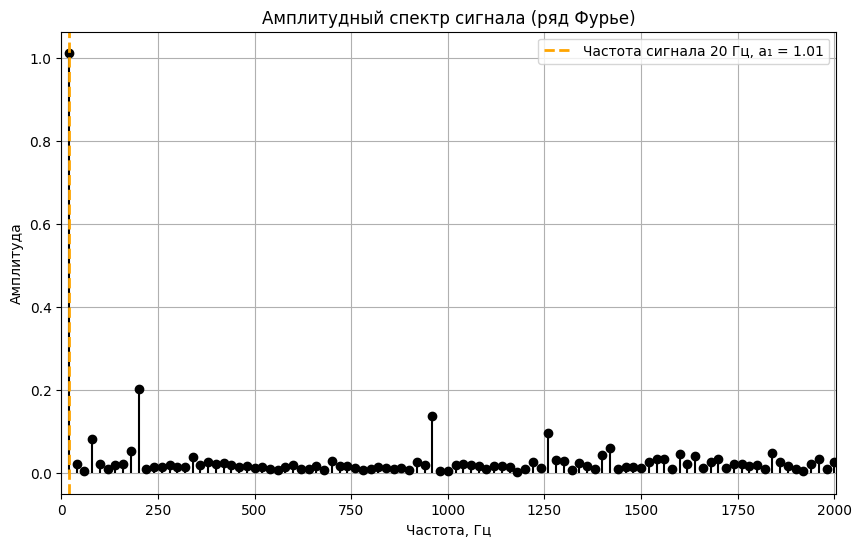

In [25]:
#-----------------------------------------------
# Задание без шума
#-----------------------------------------------

# Параметры сигнала 
Fs = 1000
T = 1.0
N = int(Fs * T)
t = np.arange(N) / Fs
freq = 20
A = 1
w = 2 * np.pi * freq
clean_signal = A * np.cos(w * t)

x_t_cos = [cos_A(t) for t in t]

furry = Fourie(cos_A, 1 / freq, t, 100)

furry.compute_row()

row = furry.get_row()


plt.figure(figsize=(20, 5)) 
plt.plot(t, x_t_cos, label="target_function", linewidth=5)

plt.grid(True)
plt.legend()
# plt.show()
plt.plot(t, row, label="fourie")
# plt.axis('equal')
plt.xlim(-0.5, 1.5)

plt.grid(True)
plt.legend()
plt.show()

f0 = freq  # основная частота (Гц)
n_harmonics = np.arange(1, furry.N + 1)  # номера гармоник от 1 до N
harmonics_freq = n_harmonics * f0        # частоты гармоник

# Амплитуды гармоник (для n >= 1)
amplitudes = [np.sqrt(furry.an[i]**2 + furry.bn[i]**2) for i in range(furry.N)]

# Поиск индекса основной гармоники (n=1) — это первый элемент
idx_fundamental = 0
a1 = furry.an[idx_fundamental]          # спектральный коэффициент a1
amp1 = amplitudes[idx_fundamental]       # амплитуда первой гармоники

print(f'Спектральный коэффициент a1 = {a1:.4f} (ожидается A = {A})')
print(f'Амплитуда первой гармоники = {amp1:.4f}')

# Создаём новый рисунок для спектра
plt.figure(figsize=(10, 6))

# Изображаем спектр в виде вертикальных линий (stem-plot)
plt.stem(harmonics_freq, amplitudes, basefmt=" ", linefmt='k-', markerfmt='ko')
plt.title('Амплитудный спектр сигнала (ряд Фурье)')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

# Отмечаем частоту сигнала оранжевой пунктирной линией
plt.axvline(x=f0, color='orange', linestyle='--', linewidth=2,
            label=f'Частота сигнала {f0} Гц, a₁ = {a1:.2f}')

plt.legend()
plt.xlim(0, max(harmonics_freq) + 5)  # небольшой запас справа
plt.show()

#--------------
# Теперь с шумом
#--------------


# Добавляем шум с std = 0.2 (примерно 20% от амплитуды)
noise_std = 0.2
noise = np.random.normal(0, noise_std, N)
noisy_signal = clean_signal + noise

def noisy_cos(t):
    noise_std = 0.2
    noise = np.random.normal(0, noise_std, 1)
    return A * np.cos(w * t) + noise

noisy_furry = Fourie(noisy_cos, 1 / freq, t, 100)

noisy_furry.compute_row()

noisy_row = noisy_furry.get_row()

x_noisy_cos = [noisy_cos(t) for t in t]

plt.figure(figsize=(20, 5)) 
plt.plot(t, x_noisy_cos, label="target_function", linewidth=5)
plt.grid(True)
plt.legend()
# plt.show()
plt.plot(t, noisy_row, label="fourie")
# plt.axis('equal')
plt.xlim(-0.5, 1.5)

plt.grid(True)
plt.legend()
plt.show()

f0 = freq  # основная частота (Гц)
n_harmonics = np.arange(1, noisy_furry.N + 1)  # номера гармоник от 1 до N
harmonics_freq = n_harmonics * f0        # частоты гармоник

# Амплитуды гармоник (для n >= 1)
amplitudes = [np.sqrt(noisy_furry.an[i]**2 + noisy_furry.bn[i]**2) for i in range(noisy_furry.N)]

# Поиск индекса основной гармоники (n=1) — это первый элемент
idx_fundamental = 0
a1 = noisy_furry.an[idx_fundamental]          # спектральный коэффициент a1
amp1 = amplitudes[idx_fundamental]       # амплитуда первой гармоники

print(f'Спектральный коэффициент a1 = {a1:.4f} (ожидается A = {A})')
print(f'Амплитуда первой гармоники = {amp1:.4f}')

# Создаём новый рисунок для спектра
plt.figure(figsize=(10, 6))

# Изображаем спектр в виде вертикальных линий (stem-plot)
plt.stem(harmonics_freq, amplitudes, basefmt=" ", linefmt='k-', markerfmt='ko')
plt.title('Амплитудный спектр сигнала (ряд Фурье)')
plt.xlabel('Частота, Гц')
plt.ylabel('Амплитуда')
plt.grid(True)

# Отмечаем частоту сигнала оранжевой пунктирной линией
plt.axvline(x=f0, color='orange', linestyle='--', linewidth=2,
            label=f'Частота сигнала {f0} Гц, a₁ = {a1:.2f}')

plt.legend()
plt.xlim(0, max(harmonics_freq) + 5)  # небольшой запас справа
plt.show()



# Визуализация
# plt.figure(figsize=(12, 4))
# plt.plot(t[:200], clean_signal[:200], 'b-', label='Чистый сигнал')
# plt.plot(t[:200], noisy_signal[:200], 'r-', alpha=0.7, label='Сигнал + шум')
# plt.xlabel('Время, с')
# plt.ylabel('Амплитуда')
# plt.legend()
# plt.grid(True)
# plt.title('Добавление шума (std = 0.2)')
# plt.show()